# Sentiment vs. Stock Market Performance
## Does Consumer Confidence Actually Drive Equity Returns?

> *At a time of geopolitical chaos and historically low consumer sentiment, the stock market has been surging. This project investigates whether consumer sentiment has ever reliably predicted stock market returns and what actually drives market performance.*

**Author:** Christopher Lee  
**Data Sources:** FRED (UMCSENT), Yahoo Finance (yfinance), Macrotrends (P/E ratio)  
**Tools:** Python, Pandas, SciPy, Matplotlib, yfinance


## 1. Imports & Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs
import yfinance as yf
from scipy import stats
from fredapi import Fred

## 2. Data Collection

Three datasets are used:
- **UMCSENT** — University of Michigan Consumer Sentiment Index (FRED), monthly, 1979–present
- **S&P 500** — Price history from Yahoo Finance (`^GSPC`), resampled to monthly
- **P/E Ratio** — Historical S&P 500 P/E ratio from Macrotrends


### 2a. Consumer Sentiment (FRED)

In [3]:
# Load consumer sentiment data from FRED CSV download
sent = pd.read_csv('UMCSENT.csv')
sent.rename(columns={'observation_date': 'Date', 'UMCSENT': 'Sentiment'}, inplace=True)
sent['Date'] = pd.to_datetime(sent['Date'])
sent = sent.copy()

# Filter to start from Volcker era (1979) for relevant historical context
sent = sent[sent['Date'] >= '1979-01-01'].reset_index(drop=True)
sent.head()

,Date,Sentiment
0,1979-01-01,72.1
1,1979-02-01,73.9
2,1979-03-01,68.4
3,1979-04-01,66.0
4,1979-05-01,68.1


### 2b. S&P 500 Price Data (yfinance)

In [4]:
# Pull S&P 500 index price history
sp500 = yf.Ticker('^GSPC')
sp500 = sp500.history(start='1979-01-01', end='2026-05-01')
price_stocks = sp500[['Close']]

# Remove timezone info and resample daily data to monthly
price_stocks.index = price_stocks.index.tz_convert(None)
price_stocks = price_stocks.resample('MS').mean()
price_stocks = price_stocks.reset_index()
price_stocks.head()

,Date,Close
0,1979-01-01,99.705001
1,1979-02-01,98.229474
2,1979-03-01,100.112273
3,1979-04-01,102.066000
4,1979-05-01,99.727727


### 2c. P/E Ratio (Macrotrends)

In [5]:
# Load historical S&P 500 P/E ratio
pe_df = pd.read_csv('pe-ratio.csv', skiprows=16, names=['Date', 'pe_ratio'])
pe_df['Date'] = pd.to_datetime(pe_df['Date'])
pe_df = pe_df[pe_df['Date'] >= '1979-01-01'].reset_index(drop=True)
pe_df.head()

,Date,pe_ratio
0,1979-01-01,7.5135
1,1979-02-01,7.2391
2,1979-03-01,7.6383
3,1979-04-01,7.2790
4,1979-05-01,7.0873


## 3. Data Cleaning & Merging

Key cleaning steps:
- Convert all date columns to `datetime64` for consistent merging
- Align sentiment (monthly, 1st of month) with price data (monthly start)
- Calculate monthly returns using `pct_change()` — more meaningful than raw price for correlation
- Remove outlier P/E values (>100) caused by earnings collapses during COVID and dot-com crash


In [6]:
# Merge sentiment and S&P 500 price on date
merged = pd.merge(price_stocks, sent, on='Date', how='inner')

# Calculate monthly returns (more accurate than raw price for correlation analysis)
# Raw price always trends upward due to inflation — returns remove this bias
merged['returns'] = merged['Close'].pct_change()
merged = merged.dropna(subset=['returns'])

# Create lagged sentiment (does last month's sentiment predict this month's returns?)
merged['sentiment_lagged'] = merged['Sentiment'].shift(1)
merged = merged.dropna(subset=['sentiment_lagged'])

print(f'Merged dataset shape: {merged.shape}')
print(f'Date range: {merged["Date"].min()} to {merged["Date"].max()}')
merged.head()

Merged dataset shape: (566, 5)
Date range: 1979-03-01 00:00:00 to 2026-04-01 00:00:00


,Date,Close,Sentiment,returns,sentiment_lagged
2,1979-03-01,100.112273,68.4,0.019167,73.9
3,1979-04-01,102.066000,66.0,0.019515,68.4
4,1979-05-01,99.727727,68.1,-0.022909,66.0
5,1979-06-01,101.727619,65.8,0.020054,68.1
6,1979-07-01,102.711428,60.4,0.009671,65.8


In [7]:
# Merge P/E data with sentiment for supplementary analysis
peMerged = pd.merge(pe_df, sent, on='Date', how='inner')

# Remove extreme P/E outliers (>100) — these occur when earnings collapse near zero
# (e.g. COVID crash, dot-com bust) and distort correlation results
peMerged = peMerged[peMerged['pe_ratio'] < 100]
print(f'P/E dataset shape: {peMerged.shape}')

P/E dataset shape: (561, 3)


## 4. Exploratory Data Analysis

Before testing our hypothesis, we examine the distribution and trends of each variable.


In [8]:
# Summary statistics
merged[['Sentiment', 'returns', 'Close']].describe().round(4)

,Sentiment,returns,Close
count,566.0000,566.0000,566.0000
mean,84.0661,0.0082,1481.7925
std,14.0052,0.0356,1505.2377
min,49.8000,-0.2040,99.7277
25%,72.9500,-0.0078,360.1199
50%,88.3000,0.0110,1120.0750
75%,94.4000,0.0299,1915.0530
max,112.0000,0.1202,6957.0076


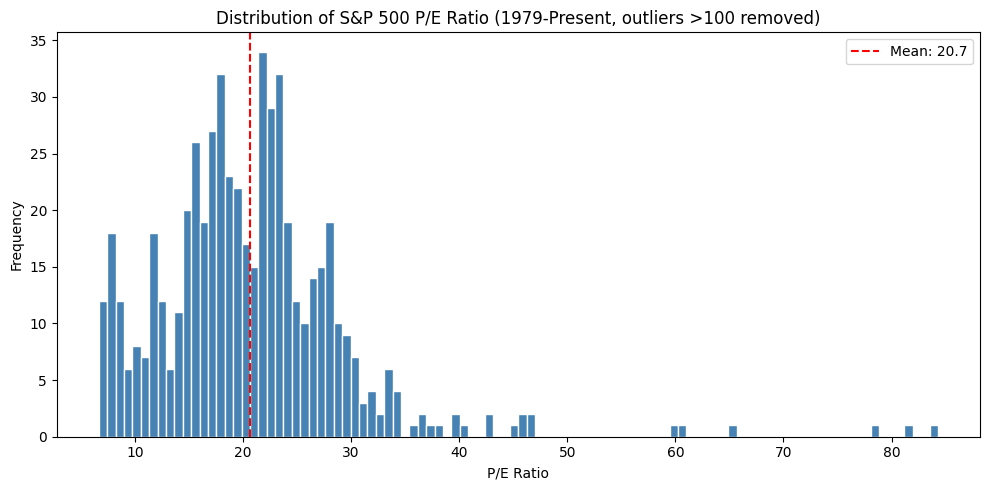

In [9]:
# P/E ratio distribution
# Note: most values cluster between 10-30 (normal range)
# Extreme outliers above 60 correspond to COVID crash and dot-com bust
plt.figure(figsize=(10, 5))
plt.hist(peMerged['pe_ratio'], bins=100, color='steelblue', edgecolor='white')
plt.title('Distribution of S&P 500 P/E Ratio (1979-Present, outliers >100 removed)')
plt.xlabel('P/E Ratio')
plt.ylabel('Frequency')
plt.axvline(peMerged['pe_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {peMerged["pe_ratio"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Hypothesis Testing — Sentiment vs. Returns

**Null Hypothesis (H₀):** There is no significant correlation between consumer sentiment and S&P 500 monthly returns.  
**Alternative Hypothesis (H₁):** There is a significant correlation between consumer sentiment and S&P 500 monthly returns.

We use the **Pearson correlation test**, which gives us:
- **r** — correlation coefficient (strength and direction)
- **p-value** — statistical significance (threshold: p < 0.05)

### 5a. Overall Correlation (1979–Present)


In [10]:
# Pearson correlation: sentiment vs monthly returns (full window)
r_return, p_return = stats.pearsonr(merged['returns'], merged['Sentiment'])
print(f'Correlation coefficient (r): {r_return:.4f}')
print(f'P-value: {p_return:.4f}')
print()
if p_return < 0.05:
    print(f'Result: SIGNIFICANT — reject null hypothesis')
else:
    print(f'Result: NOT SIGNIFICANT — fail to reject null hypothesis')
print()
print('Interpretation: r ≈ 0 suggests consumer sentiment has virtually no')
print('historical relationship with monthly S&P 500 returns.')

Correlation coefficient (r): 0.0716
P-value: 0.0888

Result: NOT SIGNIFICANT — fail to reject null hypothesis

Interpretation: r ≈ 0 suggests consumer sentiment has virtually no
historical relationship with monthly S&P 500 returns.


### 5b. Supplementary: Sentiment vs. P/E Ratio

P/E ratio measures valuation (how expensive stocks are relative to earnings).  
This tests whether sentiment aligns with market *valuation*, not just performance.


In [11]:
# Pearson correlation: sentiment vs P/E ratio
r2, p2 = stats.pearsonr(peMerged['Sentiment'], peMerged['pe_ratio'])
print(f'r = {r2:.4f}, p = {p2:.4f}')
print()
print('Interpretation: Even weaker correlation (-0.08) confirms sentiment')
print('does not drive how expensive stocks are relative to earnings.')

r = 0.0480, p = 0.2563

Interpretation: Even weaker correlation (-0.08) confirms sentiment
does not drive how expensive stocks are relative to earnings.


### 5c. Era Breakdown — Does the Correlation Differ Across Historical Periods?

In [12]:
# Define key economic eras
era = {
    'Volcker (1979-1987)':        ('1979-01-01', '1987-12-01'),
    'Black Monday (1987)':        ('1987-01-01', '1988-12-01'),
    'Dot-com Bubble (1995-2000)': ('1995-01-01', '2000-12-01'),
    'Dot-com Crash (2000-2002)':  ('2000-01-01', '2002-12-01'),
    '2008 Crisis (2007-2009)':    ('2007-01-01', '2009-12-01'),
    'COVID Crash (2020)':         ('2020-01-01', '2020-12-01'),
    'Post-COVID Boom (2021)':     ('2021-01-01', '2021-12-01'),
    'Rate Hikes (2022-2023)':     ('2022-01-01', '2023-12-01'),
    'Current (2024-present)':     ('2024-01-01', '2026-04-01')
}

times = {}
for event, (start, end) in era.items():
    mask = (merged['Date'] >= pd.to_datetime(start)) & (merged['Date'] <= pd.to_datetime(end))
    era_df = merged[mask]
    r_era, p_era = stats.pearsonr(era_df['returns'], era_df['sentiment_lagged'])
    times[event] = [r_era, p_era]

times_df = pd.DataFrame(times, index=['r', 'p_value']).T
times_df['significant'] = times_df['p_value'] < 0.05
times_df.round(4)

,r,p_value,significant
Volcker (1979-1987),-0.0730,0.4569,False
Black Monday (1987),0.0021,0.9924,False
Dot-com Bubble (1995-2000),-0.1922,0.1058,False
Dot-com Crash (2000-2002),-0.0813,0.6372,False
2008 Crisis (2007-2009),0.0983,0.5686,False
COVID Crash (2020),-0.5911,0.0430,True
Post-COVID Boom (2021),0.3728,0.2327,False
Rate Hikes (2022-2023),-0.2758,0.1920,False
Current (2024-present),-0.0102,0.9591,False


## 6. Visualizations

### 6a. S&P 500 Annual Returns vs Consumer Sentiment (1979–Present)

The dual-axis chart shows both variables over time. Key observation: even during periods of 
very low sentiment, returns often remained positive — supporting our finding of weak correlation.


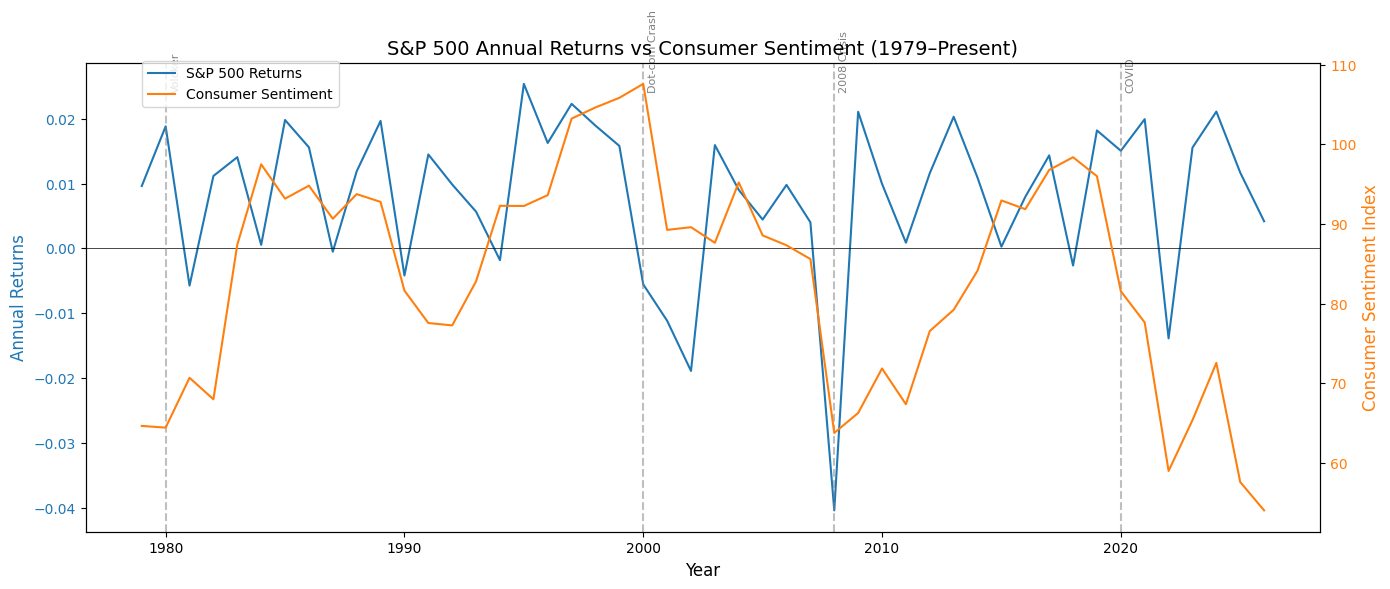

In [13]:
# Aggregate to yearly averages for a cleaner chart
merged['year'] = merged['Date'].dt.year
yearly = merged.groupby('year')[['Sentiment', 'returns']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Returns (left axis)
ax1.plot(yearly['year'], yearly['returns'], color='C0', linewidth=1.5, label='S&P 500 Returns')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Annual Returns', color='C0', fontsize=12)
ax1.tick_params(axis='y', labelcolor='C0')
ax1.axhline(0, color='black', linewidth=0.5, linestyle='-')

# Sentiment (right axis)
ax2 = ax1.twinx()
ax2.plot(yearly['year'], yearly['Sentiment'], color='C1', linewidth=1.5, label='Consumer Sentiment')
ax2.set_ylabel('Consumer Sentiment Index', color='C1', fontsize=12)
ax2.tick_params(axis='y', labelcolor='C1')

# Annotate key events
events = {2008: '2008 Crisis', 2000: 'Dot-com Crash', 2020: 'COVID', 1980: 'Volcker'}
for year, label in events.items():
    ax1.axvline(x=year, color='grey', linestyle='--', alpha=0.5)
    ax1.text(year + 0.2, ax1.get_ylim()[1] * 0.85, label, fontsize=8, color='grey', rotation=90)

plt.title('S&P 500 Annual Returns vs Consumer Sentiment (1979–Present)', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

### 6b. Sector Cumulative Returns (2022–Present)

[*********************100%***********************]  7 of 7 completed


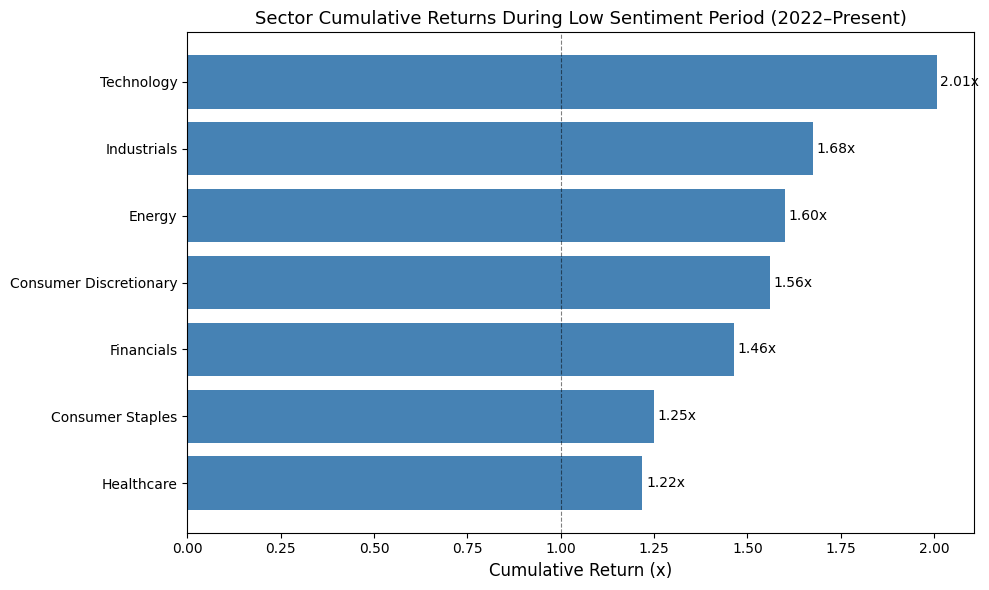

In [15]:
# Download sector ETF data
sectors = ['XLK', 'XLF', 'XLE', 'XLY', 'XLP', 'XLV', 'XLI']
data = yf.download(sectors, start='2023-03-01', end='2026-04-01')['Close']
data.rename(columns={
    'XLE': 'Energy', 'XLF': 'Financials', 'XLI': 'Industrials',
    'XLK': 'Technology', 'XLP': 'Consumer Staples',
    'XLV': 'Healthcare', 'XLY': 'Consumer Discretionary'
}, inplace=True)

# Calculate daily returns and cumulative returns
sector_returns = data.pct_change().dropna()
total_return = (1 + sector_returns).cumprod().iloc[-1].reset_index()
total_return.columns = ['Sector', 'Total Returns']
total_return = total_return.sort_values('Total Returns', ascending=True).reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(total_return['Sector'], total_return['Total Returns'], color='steelblue')
plt.xlabel('Cumulative Return (x)', fontsize=12)
plt.title('Sector Cumulative Returns During Low Sentiment Period (2022–Present)', fontsize=13)
plt.axvline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Add value labels
for bar, val in zip(bars, total_return['Total Returns']):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}x', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Conclusions

### Key Findings

1. **Sentiment and returns are not significantly correlated** (r = 0.073, p > 0.05 overall)  
   The popular assumption that consumer sentiment drives stock market performance is not supported by 45 years of data.

2. **The relationship was never strong across any era**  
   Era-by-era breakdown shows almost no statistically significant correlation in any historical period, including 2008, dot-com, and Volcker. The one exception — COVID crash — showed an inverse relationship (r = -0.59), where market recovered while sentiment stayed low.

3. **All sectors posted strong returns despite historic low sentiment (2022–present)**  
   Technology led (2.0x) but industrials, energy, and financials all posted strong cumulative returns — suggesting broad market strength disconnected from consumer confidence.

4. **Sentiment measures Main Street; markets reflect Wall Street**  
   The S&P 500 is driven by corporate earnings, institutional capital, and AI-fueled mega-cap growth — not the feelings of average consumers. The Magnificent 7 alone represented ~34% of the S&P 500 by December 2025, up from 12% in 2015.

### Limitations

- Monthly data may be too coarse to capture short-term sentiment-return dynamics
- P/E ratio as a valuation metric has known limitations (backward-looking, earnings manipulation)
- Sector ETF analysis starts post-pandemic due to data availability
- Small sample sizes in some eras reduce statistical power

### What I'd Investigate Next

- Compare equal-weighted vs market-cap weighted S&P 500 returns to quantify Mag 7 concentration effect
- Add interest rate (Federal Funds Rate) as a control variable
- Analyze sentiment by income bracket to test the wealth concentration hypothesis
